# Demosaicing and High Dynamic Range (Parts 1-8)

Building a full RAW image processing pipeline from scratch, including Bayer pattern analysis, demosaicing, luminosity correction, white balance, HDR imaging, and tone mapping.

## Pipeline Overview
1. **Bayer Pattern Investigation**: identify the sensor's color filter arrangement
2. **Demosaicing**: reconstruct full RGB from raw sensor data using convolution
3. **Luminosity Improvement**: apply gamma correction with percentile normalization
4. **White Balance**: implement Gray World algorithm
5. **Sensor Linearity**: verify that raw sensor values scale linearly with exposure time
6. **Initial HDR**: merge multi-exposure RAW images into an HDR image
7. **iCAM06 Tone Mapping**: apply perceptually-based tone mapping
8. **Full Pipeline (`process_raw`)**: end-to-end function from RAW file to output JPG

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import cv2
import rawpy
from scipy.signal import convolve2d


In [12]:
# Define a function to plot the images

def plot_img(img, title, axis="off", cmap=None):
    plt.imshow(img, cmap=cmap)
    plt.axis(axis)
    plt.title(title)
    plt.show()

## 1- Investigate Bayer Patterns

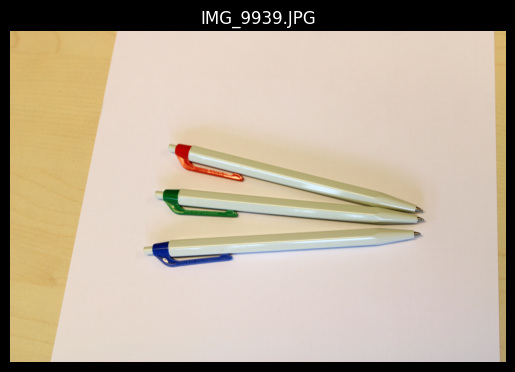

In [13]:
img_path = "./res/01/IMG_9939.JPG"

# Load JPG file and show the image
img = mpimg.imread(img_path)
plot_img(img, title='IMG_9939.JPG')

Shape of the image as a numpy array: (4014, 6020)


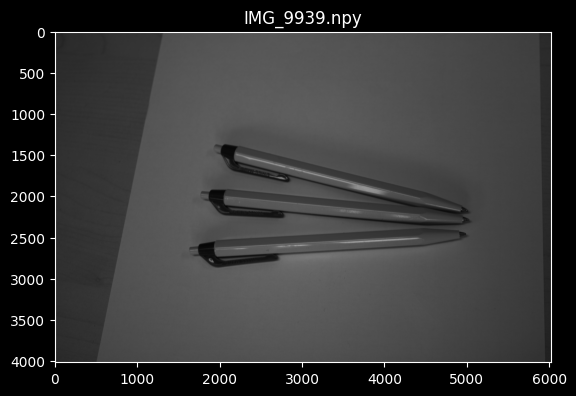

In [14]:
# Load the numpy array

array = np.load("./res/01/IMG_9939.npy")
print("Shape of the image as a numpy array:", array.shape)

plot_img(array, 'IMG_9939.npy', axis='on', cmap='gray')


In [15]:
# Select different color regions of the array and print their values 
# Then by comparing all of these values together, we can find the Bayer patters of the image


# Define region for Red area of the image: rows (y1:y2), cols (x1:x2)
y1, y2 = 2050, 2060   # height range of Red pen
x1, x2 = 1450, 1460   # width range of Red pen

red_area = array[x1:x2, y1:y2]  # get the Red area
print("Red area values:\n", red_area, '\n')


# Define region for Green area
y1, y2 = 1950, 1960   # height range of Green pen
x1, x2 = 1950, 1960   # width range of Green pen 

green_area = array[x1:x2, y1:y2]  # get the Green area
print("Green area values:\n", green_area, '\n')


# Define regions for Blue area
y1, y2 = 1650, 1660   # height range of Blue area
x1, x2 = 1800, 1810   # width range of Blue area

blue_area = array[x1:x2, y1:y2]  # get the Blue area
print("Blue area values:\n", blue_area, '\n')


# Define regions for White area
y1, y2 = 3000, 3010   # height range of White paper
x1, x2 = 3000, 3010   # width range of white paper

white_area = array[x1:x2, y1:y2]  # get the white area
print("White area values:\n", white_area, '\n')

Red area values:
 [[2335 2150 2361 2143 2357 2144 2350 2156 2355 2139]
 [2679 2326 2680 2332 2670 2368 2691 2361 2710 2357]
 [2370 2167 2366 2149 2367 2149 2340 2157 2351 2145]
 [2660 2379 2676 2352 2675 2351 2667 2359 2657 2340]
 [2342 2157 2358 2150 2376 2145 2324 2155 2333 2121]
 [2697 2344 2709 2362 2688 2375 2667 2336 2663 2344]
 [2356 2146 2361 2156 2358 2134 2380 2147 2358 2134]
 [2697 2354 2704 2345 2660 2337 2712 2331 2689 2354]
 [2376 2150 2347 2136 2338 2148 2350 2155 2337 2135]
 [2660 2361 2695 2371 2668 2387 2679 2333 2683 2364]] 

Green area values:
 [[2402 2169 2389 2165 2397 2169 2389 2161 2395 2164]
 [2129 2411 2176 2421 2145 2390 2160 2399 2146 2420]
 [2422 2166 2379 2182 2411 2158 2399 2152 2393 2164]
 [2136 2395 2170 2402 2153 2413 2146 2385 2143 2418]
 [2395 2155 2399 2174 2392 2186 2377 2164 2408 2166]
 [2151 2400 2147 2406 2141 2399 2160 2403 2135 2384]
 [2435 2174 2424 2184 2429 2176 2384 2172 2392 2174]
 [2157 2419 2154 2419 2150 2421 2154 2401 2129 2403]
 [241

After Comparing all of these values of each color region together, we found that the Bayer Pattern for the image is: GBRG

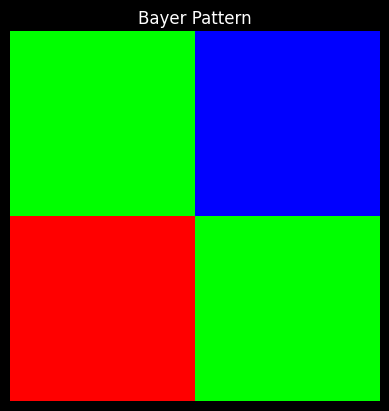

In [16]:
# Plot the result of the founded bayer pattern

# Create a simple block for the GBRG pattern
bayer_pattern = np.array([
    [[0,1,0], [0,0,1]],
    [[1,0,0], [0,1,0]]], dtype=float)

plot_img(bayer_pattern, 'Bayer Pattern')

## 2- Implement a Demosaicing Algorithm

In [17]:
def demosaicing(raw_data):
    """ 
    Apply demosaicing algorithm to the raw image data

    Args:
        raw_data: raw image data

    Returns: 
        red_channel: a np array for red channel of the image
        green_channel: a np array for green channel of the image
        blue_channel: a np array for blue channel of the image
    """

    # Create a mask for each color channel
    red_mask = np.zeros_like(raw_data)
    green_mask = np.zeros_like(raw_data)
    blue_mask = np.zeros_like(raw_data)

    # Set the values for each color mask
    red_mask[0::2, 0::2] = 1     # red values at even rows, even cols
    green_mask[0::2, 1::2] = 1   # green values at even rows, odd cols
    green_mask[1::2, 0::2] = 1   # green values also at odd rows, even cols
    blue_mask[1::2, 1::2] = 1    # blue values at odd rows, odd cols

    # Create a convolution kernel
    kernel = np.ones((3, 3))

    # Calculating each color channel using the formula:
    # color_channel = ((color_mask x data) ⊗ kernel) / (color_mask ⊗ kernel)
    
    array_red = red_mask * raw_data 
    array_green = green_mask * raw_data
    array_blue = blue_mask * raw_data

    red_channel = convolve2d(array_red, kernel, mode="same") / convolve2d(red_mask, kernel, mode="same")
    green_channel = convolve2d(array_green, kernel, mode="same") / convolve2d(green_mask, kernel, mode="same")
    blue_channel = convolve2d(array_blue, kernel, mode="same") / convolve2d(blue_mask, kernel, mode="same")

    return red_channel, green_channel, blue_channel

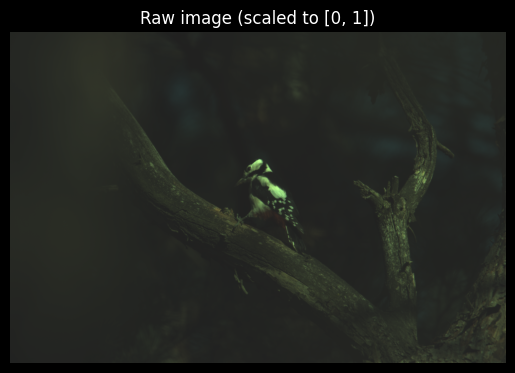

In [18]:
# Load the raw sensor data
raw_img = rawpy.imread("./res/02/IMG_4782.CR3")
raw_data = np.array(raw_img.raw_image_visible)

# Apply the demosaicing algorithm to our raw input data to get RGB channels
red_channel, green_channel, blue_channel = demosaicing(raw_data)

# Combine all three channels to get the whole image
img = np.dstack((red_channel, green_channel, blue_channel))

plot_img(img / np.max(img), 'Raw image (scaled to [0, 1])')

## 3- Improve the Luminosity

In [19]:
def improve_luminosity(data, gamma = 0.3):
    """ 
    Improve the luminosity of the image. While after applying demosaicing the output image
    is too dark. By applying a gamma correction, we can fix this issue. 
    
    Args:
        data: image data
        gamma: gamma value used for gamma correction

    Returns: 
        data: image data after applying gamma correction
        
    """

    # Normalize the values using percentiles
    a = np.percentile(data, 0.01)
    b = np.percentile(data, 99.99)
    data = (data - a) / (b-a)
    data[data<0] = 0
    data[data>1] = 1

    # apply gamma correction
    data = np.power(data, gamma)

    data_rescaled = data * (b - a) + a
    
    return data, data_rescaled

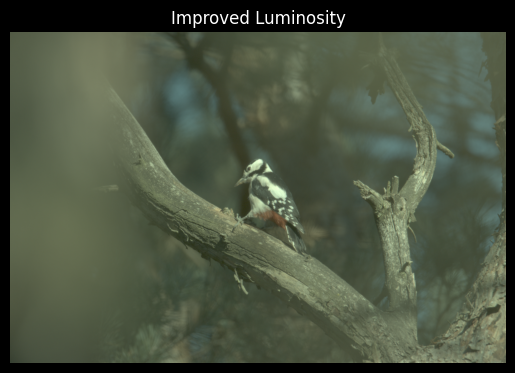

In [20]:
# Apply luminosity improvement on the image

gamma_corrected_img, gamma_corrected_img_scaled = improve_luminosity(img, gamma=0.3)
plot_img(gamma_corrected_img, 'Improved Luminosity')

## 4- White Balance

In [21]:
def apply_white_balance(image):
    """ 
    Applying white balance using Gray World algorithm
    assuming that the average color of the image is gray
    
    Args:
        image: image data
        
    Returns: 
        data: image data after applying gray world white balance algorithm
        
    """

    # Get the mean value of the image
    mean = np.mean(image)

    # Get the mean value of each color channel
    r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]

    mean_r = np.mean(r)
    mean_g = np.mean(g)
    mean_b = np.mean(b)

    # applying white balance by multiplying values of each channel by mean_image / mean_channel
    # also clip the data to a valid range
    r = np.clip(r * (mean / mean_r), 0.0, 1.0)
    g = np.clip(g * (mean / mean_g), 0.0, 1.0)
    b = np.clip(b * (mean / mean_b), 0.0, 1.0)

    return np.dstack((r, g, b))

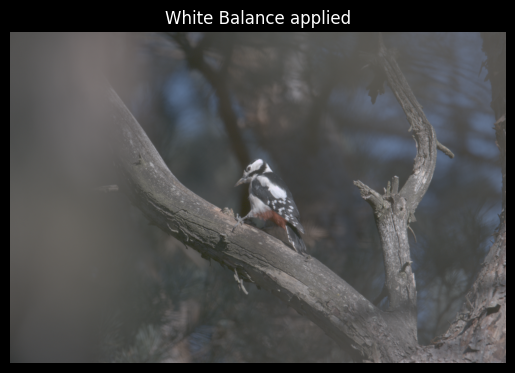

In [22]:
white_balanced_img = apply_white_balance(gamma_corrected_img)

plot_img(white_balanced_img, 'White Balance applied')

## 5- Show that Sensor Data is Linear

In [23]:
images = []
exposure_times = [1/10, 1/20, 1/40, 1/80, 1/160, 1/320]

for i in range(3044, 3050):
    file_path = os.path.join("./res/05", f"IMG_{i}.CR3")
    print(file_path)
    if os.path.exists(file_path):
        raw = rawpy.imread(file_path)
        array = np.array(raw.raw_image_visible)
        images.append(array.flatten())
    else:
        print(f"Warning: {file_path} not found")

# Calculate the average values of all images
avg_values = np.mean(images, axis=1)

./res/05/IMG_3044.CR3
./res/05/IMG_3045.CR3
./res/05/IMG_3046.CR3
./res/05/IMG_3047.CR3
./res/05/IMG_3048.CR3
./res/05/IMG_3049.CR3


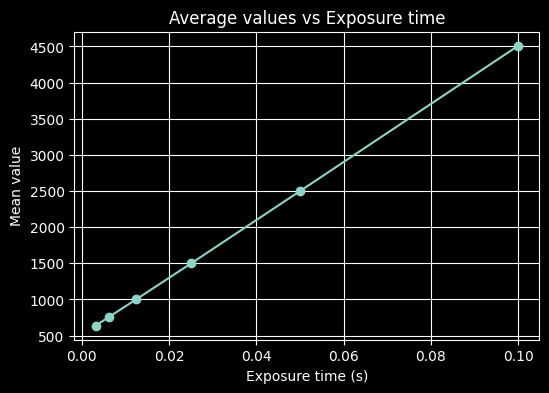

In [24]:
# Plot the result to show that the sensor data is linear

plt.figure(figsize=(6, 4))
plt.plot(exposure_times, avg_values, marker='o')
plt.xlabel("Exposure time (s)")
plt.ylabel("Mean value")
plt.title("Average values vs Exposure time")
plt.grid(True)
plt.show()

## 6- Initial HDR Implementation

In [25]:
# HDR implementation following the lecture slides
# Important: Use float32 as a datatype as int8 will quickly overflow

def apply_hdr(h_path, images_path):
    """ 
    Apply HDR merging to multi-exposure raw image data
    
    Args:
        h_path: path to the brightest image
        images_path: path of the directory containing all images

    Returns: 
        h: the output after applying HDR method
    """
    
    # Load the brightest raw data (longest exposure)
    raw = rawpy.imread(h_path)
    h = np.array(raw.raw_image_visible.astype(np.float32))

    for k in range(1, 11):
        # Load the next raw image
        img_path = os.path.join(images_path, f"{k:02d}.CR3")
        i = np.array(rawpy.imread(img_path).raw_image_visible.astype(np.float32))

        # Calculate the exposure difference to the first image and multiply by i
        exposure_difference = pow(2, k) 
        i *= exposure_difference

        # Values in h which are above a threshold t get replaced by the corresponding values in i
        t = 0.8 * np.max(h)
        replacement_mask = (h > t)
        h[replacement_mask] = i[replacement_mask]
    
    return h

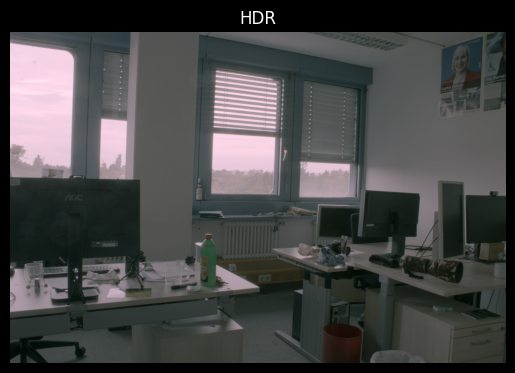

In [26]:
h = apply_hdr(h_path="./res/06/00.CR3", images_path="./res/06/")

# Apply demosaicing algorithm & white balance
red_channel, green_channel, blue_channel = demosaicing(h)

# Take logarith and put it into 0:1 range
image = np.log(np.dstack((red_channel, green_channel, blue_channel)))
image -= np.min(image)
image /= np.max(image)

# Improve luminosity (optional, but makes image brighter)
image, _ = improve_luminosity(image, gamma = 0.8)

# Apply white balance
image = apply_white_balance(image)

plot_img(image, "HDR")

## 7- iCAM06

In [27]:
def iCAM06(image, sigmaColor, sigmaSpace, output_range=4):
    """ 
    A tone mapping method with preserving details
    
    Args:
        rgb: image data
        sigmaColor: using for bilateralFilter
        sigmaSpace: using for bilateralFilter

    Returns: 
        output_rgb: the output after applying iCAM06 method
    """

    image = image.astype(np.float32)

    # Extract each color channel from the input data
    r = image[:,:,0]
    g = image[:,:,1]
    b = image[:,:,2]
    
    input_intensity = (1/61.0) * (20 * r + 40 * g + b)
    
    r = r / input_intensity
    g = g / input_intensity
    b = b / input_intensity

    # Apply bilateral filter
    log_intensity = np.log(input_intensity)
    log_base = cv2.bilateralFilter(log_intensity, d=0, sigmaColor=sigmaColor, sigmaSpace=sigmaSpace)
    log_details = log_intensity - log_base
    
    compression = np.log(output_range) / (np.max(log_base) - np.min(log_base))
    log_offset = -np.max(log_base) * compression

    output_intensity = np.exp(log_base * compression + log_offset + log_details)

    # Create the output image data using the calculated output intensity
    output_rgb = np.zeros_like(image)
    output_rgb[:,:,0] = r * output_intensity
    output_rgb[:,:,1] = g * output_intensity
    output_rgb[:,:,2] = b * output_intensity

    # Clip to the valid range for imshow
    output_rgb = np.clip(output_rgb, 0, 1)

    return output_rgb

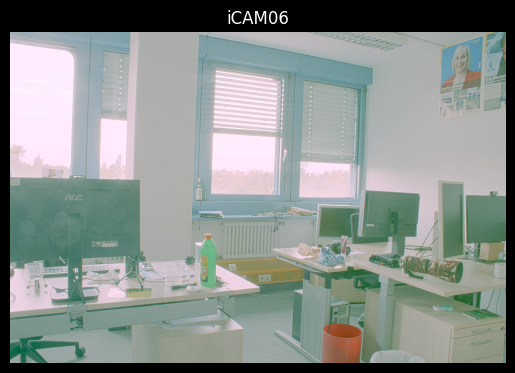

In [28]:
image_iCAM = iCAM06(image, sigmaColor=0.5, sigmaSpace=10, output_range=4)

plot_img(image_iCAM, "iCAM06")

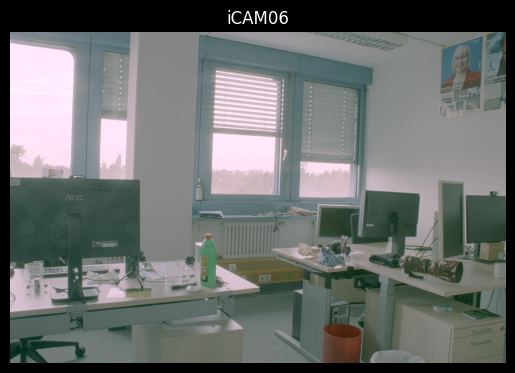

In [29]:
# Different settings for output range

image_iCAM = iCAM06(image, sigmaColor=0.5, sigmaSpace=10, output_range=10)

plot_img(image_iCAM, "iCAM06")

## 8- Win

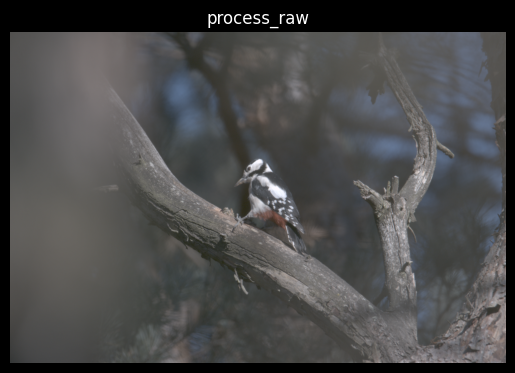

In [30]:
def process_raw(input_path, output_path):
    """
    The whole pipeline to process a raw image file
    
    Args:
        input_path: path to the input raw file
        output_path: path to save the output file

    Returns: 
        image: processed image
    """
    
    raw = rawpy.imread(input_path)
    array = np.array(raw.raw_image_visible)

    red_channel, green_channel, blue_channel = demosaicing(array)

    image = np.dstack((red_channel, green_channel, blue_channel))
    
    image, _ = improve_luminosity(image, gamma = 0.3)
    
    image = apply_white_balance(image)

    image = iCAM06(image, 0.08, 10, 12)
    
    image_to_save = (image * 255.0).clip(0, 255).astype(np.uint8)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    image_bgr = cv2.cvtColor(image_to_save, cv2.COLOR_RGB2BGR)
    cv2.imwrite(output_path, image_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 99])

    return image

image = process_raw("./res/02/IMG_4782.CR3", "./res/out/img.jpg")
plot_img(image, "process_raw")